# Bradley-Terry vs Frame Model: Prediction Comparison

For each person in the kidney pairwise data:
1. Split their comparisons into 30 train + rest as test
2. **Bradley-Terry**: fit logistic model on train, predict test
3. **Frame model (sphere)**: start with uniform sphere samples, filter by train responses, predict test via majority vote
4. Compare accuracy of both models on test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize
from scipy.spatial.distance import pdist
from typing import List, Tuple, Dict, Set, Optional
from collections import Counter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
np.random.seed(42)

from core import (
    Patient, PairwiseQuery,
    FEATURE_NAMES, FEATURE_RANGES,
    compute_frame_gaps,
)

In [2]:
# Configuration
TAU = 1.0
TAU_PRIME = 0.2
LAMBDA_X = 1.0
N_TRAIN = 30
N_SPHERE_SAMPLES = 50000

print(f"Train size: {N_TRAIN} comparisons per person")
print(f"Frame model: sphere hypothesis class, |w_i|*|gap_i| intensity")
print(f"Thresholds: tau={TAU}, tau'={TAU_PRIME}, lambda={LAMBDA_X}")
print(f"Initial sphere samples: {N_SPHERE_SAMPLES}")

Train size: 30 comparisons per person
Frame model: sphere hypothesis class, |w_i|*|gap_i| intensity
Thresholds: tau=1.0, tau'=0.2, lambda=1.0
Initial sphere samples: 50000


In [3]:
# Load data
df = pd.read_csv('kidney_pairwise_data.csv')

# Normalize all feature columns to [0, 1] using known feature ranges
feature_cols_left = ['l_elderlyDep', 'l_lifeYearsGained', 'l_obesity', 'l_weeklyWorkhours', 'l_yearsWaiting']
feature_cols_right = ['r_elderlyDep', 'r_lifeYearsGained', 'r_obesity', 'r_weeklyWorkhours', 'r_yearsWaiting']

for l_col, r_col, fname in zip(feature_cols_left, feature_cols_right, FEATURE_NAMES):
    lo, hi = FEATURE_RANGES[fname]
    span = hi - lo if hi != lo else 1.0
    df[l_col] = (df[l_col] - lo) / span
    df[r_col] = (df[r_col] - lo) / span

print("Feature normalization (min-max to [0,1]):")
for l_col, fname in zip(feature_cols_left, FEATURE_NAMES):
    lo, hi = FEATURE_RANGES[fname]
    print(f"  {fname}: [{lo}, {hi}] -> [0, 1]")

# Build query and response from each row
def row_to_query_and_response(row):
    """Convert a dataframe row to (PairwiseQuery, chosen) where chosen is 'left' or 'right'.
    Feature values are already normalized to [0, 1]."""
    left = Patient(
        elderlyDep=row['l_elderlyDep'],
        lifeYearsGained=row['l_lifeYearsGained'],
        obesity=row['l_obesity'],
        weeklyWorkhours=row['l_weeklyWorkhours'],
        yearsWaiting=row['l_yearsWaiting']
    )
    right = Patient(
        elderlyDep=row['r_elderlyDep'],
        lifeYearsGained=row['r_lifeYearsGained'],
        obesity=row['r_obesity'],
        weeklyWorkhours=row['r_weeklyWorkhours'],
        yearsWaiting=row['r_yearsWaiting']
    )
    query = PairwiseQuery(left, right)
    # chosen=1 means left, chosen=0 means right
    response = 'left' if row['chosen'] == 1 else 'right'
    return query, response

# Filter to people with enough comparisons
person_counts = df.groupby('id').size()
valid_ids = person_counts[person_counts >= N_TRAIN + 10].index.tolist()
print(f"\nPeople with >= {N_TRAIN + 10} comparisons: {len(valid_ids)}")
print(f"Total people: {df['id'].nunique()}")

Feature normalization (min-max to [0,1]):
  elderlyDep: [0, 5] -> [0, 1]
  lifeYearsGained: [0, 25] -> [0, 1]
  obesity: [0, 5] -> [0, 1]
  weeklyWorkhours: [0, 50] -> [0, 1]
  yearsWaiting: [1, 10] -> [0, 1]

People with >= 40 comparisons: 81
Total people: 82


## Model Implementations

In [4]:
# ---- Bradley-Terry ----

def fit_bt(train_queries, train_responses):
    """
    Fit Bradley-Terry via logistic regression.
    Returns weight vector w such that P(left) = sigmoid(w . delta_x).
    """
    X, y = [], []
    for query, resp in zip(train_queries, train_responses):
        delta = query.patient_left.to_array() - query.patient_right.to_array()
        X.append(delta)
        y.append(1 if resp == 'left' else 0)
    X = np.array(X)
    y = np.array(y)
    
    def neg_ll(w):
        logits = X @ w
        p = expit(logits)
        loss = -np.mean(y * np.log(p + 1e-10) + (1 - y) * np.log(1 - p + 1e-10))
        loss += 0.01 * np.sum(w**2)  # L2 regularization
        return loss
    
    w0 = np.zeros(len(FEATURE_NAMES))
    result = minimize(neg_ll, w0, method='L-BFGS-B')
    return result.x


def predict_bt(w, query):
    """Predict 'left' or 'right' using BT weights."""
    delta = query.patient_left.to_array() - query.patient_right.to_array()
    p_left = expit(np.dot(w, delta))
    return 'left' if p_left >= 0.5 else 'right'


# ---- Frame Model (Sphere, |w_i|*|gap_i|) ----

def sample_from_sphere(n_samples, dim, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    z = np.random.randn(n_samples, dim)
    norms = np.linalg.norm(z, axis=1, keepdims=True)
    return z / np.maximum(norms, 1e-10)


def filter_sphere_samples(samples, query, observed_response,
                           tau=TAU, lambda_x=LAMBDA_X, tau_prime=TAU_PRIME):
    """
    Filter sphere samples to keep those consistent with observed response.
    Uses |w_i|*|gap_i| for intensity.
    Only handles 'left'/'right' responses (the data only has these).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    if len(active_frames) == 0:
        # No active frames -> 'indifferent'; no left/right can match
        if observed_response in ('left', 'right'):
            return samples  # Can't filter, keep all
        return samples
    
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = samples[:, active_list]
    
    delta_omegas = np.dot(active_weights, active_gaps)
    r_omegas = np.dot(np.abs(active_weights), np.abs(active_gaps))
    
    # Classify each sample
    predicted = np.empty(len(samples), dtype=object)
    for idx in range(len(samples)):
        r = r_omegas[idx]
        d = delta_omegas[idx]
        if r < tau:
            predicted[idx] = 'indifferent'
        elif np.abs(d) < tau_prime * r:
            predicted[idx] = 'incomparable'
        elif d >= tau_prime * r:
            predicted[idx] = 'left'
        else:
            predicted[idx] = 'right'
    
    return samples[predicted == observed_response]


def train_frame_model(train_queries, train_responses, n_samples=N_SPHERE_SAMPLES):
    """
    Train frame model by filtering sphere samples through train transcript.
    Returns surviving samples.
    """
    dim = len(FEATURE_NAMES)
    samples = sample_from_sphere(n_samples, dim, random_state=42)
    
    for query, resp in zip(train_queries, train_responses):
        samples = filter_sphere_samples(samples, query, resp)
        if len(samples) == 0:
            break
    
    return samples


def predict_frame_model(samples, query, tau=TAU, lambda_x=LAMBDA_X, tau_prime=TAU_PRIME):
    """
    Predict by majority vote of surviving samples.
    Returns 'left' or 'right' (forced choice for comparison with data).
    """
    if len(samples) == 0:
        return 'left'  # fallback
    
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    if len(active_frames) == 0:
        return 'left'  # no info, random fallback
    
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = samples[:, active_list]
    
    delta_omegas = np.dot(active_weights, active_gaps)
    
    # Majority vote based on sign of delta
    n_left = np.sum(delta_omegas > 0)
    n_right = np.sum(delta_omegas < 0)
    
    return 'left' if n_left >= n_right else 'right'

## Run Comparison Across All People

In [5]:
results = []

for i, person_id in enumerate(valid_ids):
    person_df = df[df['id'] == person_id].copy()
    
    # Convert all rows to queries and responses
    all_data = [row_to_query_and_response(row) for _, row in person_df.iterrows()]
    
    # Random split: 30 train, rest test
    np.random.seed(person_id if isinstance(person_id, int) else hash(person_id) % 2**31)
    indices = np.random.permutation(len(all_data))
    train_idx = indices[:N_TRAIN]
    test_idx = indices[N_TRAIN:]
    
    train_queries = [all_data[j][0] for j in train_idx]
    train_responses = [all_data[j][1] for j in train_idx]
    test_queries = [all_data[j][0] for j in test_idx]
    test_responses = [all_data[j][1] for j in test_idx]
    
    n_test = len(test_queries)
    
    # --- Bradley-Terry ---
    bt_weights = fit_bt(train_queries, train_responses)
    bt_preds = [predict_bt(bt_weights, q) for q in test_queries]
    bt_correct = sum(p == r for p, r in zip(bt_preds, test_responses))
    bt_acc = bt_correct / n_test
    
    # --- Frame Model (Sphere) ---
    frame_samples = train_frame_model(train_queries, train_responses)
    n_surviving = len(frame_samples)
    
    if n_surviving > 0:
        frame_preds = [predict_frame_model(frame_samples, q) for q in test_queries]
        frame_correct = sum(p == r for p, r in zip(frame_preds, test_responses))
        frame_acc = frame_correct / n_test
    else:
        frame_preds = ['left'] * n_test  # fallback
        frame_correct = sum(p == r for p, r in zip(frame_preds, test_responses))
        frame_acc = frame_correct / n_test
    
    results.append({
        'person_id': person_id,
        'n_train': N_TRAIN,
        'n_test': n_test,
        'bt_acc': bt_acc,
        'frame_acc': frame_acc,
        'n_surviving_samples': n_surviving,
        'bt_weights': bt_weights,
        'frame_mean_weights': frame_samples.mean(axis=0) if n_surviving > 0 else None,
    })
    
    if (i + 1) % 10 == 0 or i == 0:
        print(f"Person {i+1}/{len(valid_ids)} (id={person_id}): "
              f"BT={bt_acc:.2f}, Frame={frame_acc:.2f}, "
              f"surviving={n_surviving}, test={n_test}")

print(f"\nDone! Processed {len(results)} people.")

Person 1/81 (id=1): BT=0.82, Frame=0.53, surviving=50000, test=570
Person 10/81 (id=10): BT=0.89, Frame=0.48, surviving=50000, test=570
Person 20/81 (id=21): BT=0.78, Frame=0.45, surviving=0, test=150
Person 30/81 (id=31): BT=0.89, Frame=0.47, surviving=0, test=270
Person 40/81 (id=41): BT=0.86, Frame=0.53, surviving=0, test=450
Person 50/81 (id=51): BT=0.83, Frame=0.57, surviving=0, test=150
Person 60/81 (id=61): BT=0.86, Frame=0.51, surviving=50000, test=330
Person 70/81 (id=71): BT=0.83, Frame=0.50, surviving=0, test=570
Person 80/81 (id=81): BT=0.82, Frame=0.49, surviving=50000, test=450

Done! Processed 81 people.


## Results Summary

In [6]:
results_df = pd.DataFrame(results)

print("=" * 60)
print("PREDICTION ACCURACY COMPARISON")
print("=" * 60)
print(f"Number of people: {len(results_df)}")
print(f"Train size: {N_TRAIN}, Test size: {results_df['n_test'].median():.0f} (median)")
print()
print(f"Bradley-Terry accuracy:")
print(f"  Mean: {results_df['bt_acc'].mean():.3f}")
print(f"  Median: {results_df['bt_acc'].median():.3f}")
print(f"  Std: {results_df['bt_acc'].std():.3f}")
print()
print(f"Frame model (sphere) accuracy:")
print(f"  Mean: {results_df['frame_acc'].mean():.3f}")
print(f"  Median: {results_df['frame_acc'].median():.3f}")
print(f"  Std: {results_df['frame_acc'].std():.3f}")
print()
print(f"Frame model surviving samples:")
print(f"  Mean: {results_df['n_surviving_samples'].mean():.0f}")
print(f"  Median: {results_df['n_surviving_samples'].median():.0f}")
print(f"  People with 0 surviving: {(results_df['n_surviving_samples'] == 0).sum()}")
print()
print(f"BT wins: {(results_df['bt_acc'] > results_df['frame_acc']).sum()}")
print(f"Frame wins: {(results_df['frame_acc'] > results_df['bt_acc']).sum()}")
print(f"Ties: {(results_df['bt_acc'] == results_df['frame_acc']).sum()}")

PREDICTION ACCURACY COMPARISON
Number of people: 81
Train size: 30, Test size: 450 (median)

Bradley-Terry accuracy:
  Mean: 0.831
  Median: 0.841
  Std: 0.077

Frame model (sphere) accuracy:
  Mean: 0.493
  Median: 0.498
  Std: 0.045

Frame model surviving samples:
  Mean: 13580
  Median: 0
  People with 0 surviving: 59

BT wins: 80
Frame wins: 1
Ties: 0


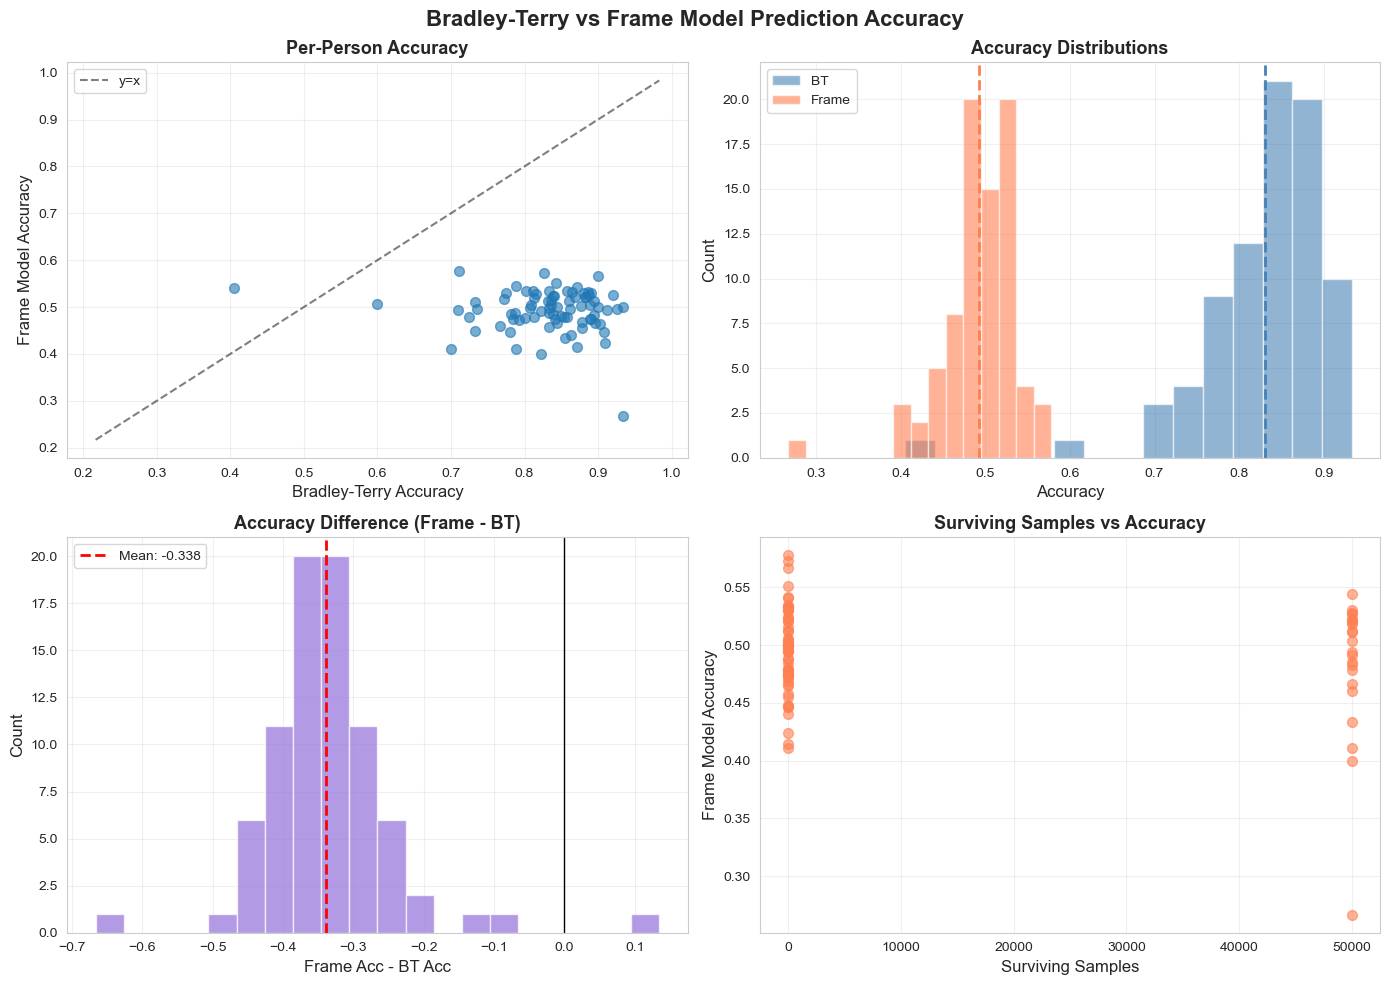

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bradley-Terry vs Frame Model Prediction Accuracy', fontsize=16, fontweight='bold')

# Plot 1: Accuracy comparison scatter
ax = axes[0, 0]
ax.scatter(results_df['bt_acc'], results_df['frame_acc'], alpha=0.6, s=50)
lims = [min(results_df['bt_acc'].min(), results_df['frame_acc'].min()) - 0.05,
        max(results_df['bt_acc'].max(), results_df['frame_acc'].max()) + 0.05]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Bradley-Terry Accuracy', fontsize=12)
ax.set_ylabel('Frame Model Accuracy', fontsize=12)
ax.set_title('Per-Person Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy distributions
ax = axes[0, 1]
ax.hist(results_df['bt_acc'], bins=15, alpha=0.6, label='BT', color='steelblue')
ax.hist(results_df['frame_acc'], bins=15, alpha=0.6, label='Frame', color='coral')
ax.axvline(results_df['bt_acc'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(results_df['frame_acc'].mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Accuracy Distributions', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Accuracy difference
ax = axes[1, 0]
diff = results_df['frame_acc'] - results_df['bt_acc']
ax.hist(diff, bins=20, alpha=0.7, color='mediumpurple')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.axvline(diff.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {diff.mean():.3f}')
ax.set_xlabel('Frame Acc - BT Acc', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Accuracy Difference (Frame - BT)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Surviving samples vs frame accuracy
ax = axes[1, 1]
ax.scatter(results_df['n_surviving_samples'], results_df['frame_acc'], alpha=0.6, s=50, color='coral')
ax.set_xlabel('Surviving Samples', fontsize=12)
ax.set_ylabel('Frame Model Accuracy', fontsize=12)
ax.set_title('Surviving Samples vs Accuracy', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Show per-person details sorted by frame model advantage
results_df['diff'] = results_df['frame_acc'] - results_df['bt_acc']
display_cols = ['person_id', 'n_test', 'bt_acc', 'frame_acc', 'diff', 'n_surviving_samples']
print("Per-person results (sorted by frame advantage):")
print(results_df[display_cols].sort_values('diff', ascending=False).to_string(index=False))

Per-person results (sorted by frame advantage):
 person_id  n_test   bt_acc  frame_acc      diff  n_surviving_samples
        39      37 0.405405   0.540541  0.135135                    0
        80     150 0.600000   0.506667 -0.093333                    0
        82      90 0.711111   0.577778 -0.133333                    0
         4     330 0.709091   0.493939 -0.215152                50000
        58      90 0.733333   0.511111 -0.222222                50000
        40     460 0.734783   0.495652 -0.239130                    0
        28     390 0.774359   0.530769 -0.243590                    0
        27      90 0.788889   0.544444 -0.244444                50000
        37     450 0.724444   0.477778 -0.246667                    0
        51     150 0.826667   0.573333 -0.253333                    0
        78     390 0.771795   0.517949 -0.253846                50000
        32     570 0.801754   0.535088 -0.266667                    0
        29      90 0.811111   0.533333 -0.